# Notebook 04 - Cross-Method Validation

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Upstream:** NB02b (z-score flags), NB03 (Isolation Forest flags), SAS `02_peer_comparison.sas`  
**Downstream:** NB05 (business impact & triage)

---

## Purpose

This notebook answers the central question of the project: **"Do providers flagged by statistics look the same as providers flagged by machine learning?"**

Three independent detection methods produced flags:
- **Z-scores** (NB02b): within-peer-group statistical outliers, conjunction rule (≥2 metrics at |z|>2.0)
- **Isolation Forest** (NB03): global multivariate anomalies, distribution-free
- **SAS PROC STDIZE + PROC RANK** (if available): cross-technology validation

This notebook builds the **two-gate confidence matrix** that classifies providers into actionable audit tiers:

| Tier | Criteria | Action |
|---|---|---|
| **Tier 1 - High confidence** | Flagged by BOTH z-score AND IF | Immediate audit & record request |
| **Tier 2 - Multivariate aberrance** | Flagged by IF only | Complex unbundling/interaction review |
| **Tier 3 - Statistical outlier** | Flagged by z-score only | Single-metric policy limit enforcement |
| Unflagged | Neither method | Routine monitoring |

The **divergence analysis** examines WHY the methods disagree - is it specialty-scale artifacts (Level II codes dominating IF flags) or genuine complementary detection (different FWA typologies)?

In [ ]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy import stats
from sklearn.metrics import cohen_kappa_score, confusion_matrix

warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.8f}')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('YOUR FOLDER')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR, OUTPUT_DIR, SNOWFLAKE_EXPORTS_DIR,
    Z_THRESHOLD_PRIMARY, Z_THRESHOLD_SEVERE,
)
from src.visual_identity import *
from src.data_loader import load_snowflake_export

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans


## 1. Load detection results

In [24]:
# =============================================================================
# Load NB03 export - contains z-scores, IF, and LOF flags
# =============================================================================

def _safe_bool(series):
    """Cast to bool safely — handles 0/1, True/False, and string 'TRUE'/'FALSE'."""
    if series.dtype == object:
        return series.str.upper().map({'TRUE': True, 'FALSE': False, '1': True, '0': False}).fillna(False)
    return series.astype(bool)

input_path = OUTPUT_DIR / 'nb03_provider_anomaly_scores.csv'
df = pd.read_csv(input_path)
print(f"Loaded: {len(df):,} providers × {len(df.columns)} cols")

# Ensure boolean flags
df['flag_zscore_2'] = _safe_bool(df['flag_zscore_2'])
df['if_flag'] = _safe_bool(df['if_flag'])

print(f"  Z-score flagged (≥2 metrics |z|>{Z_THRESHOLD_PRIMARY}): {df['flag_zscore_2'].sum():,}")
print(f"  IF flagged (contamination=0.05): {df['if_flag'].sum():,}")

# Try loading SAS flags
sas_path = OUTPUT_DIR / 'sas_provider_flags.csv'
has_sas = sas_path.exists()
if has_sas:
    df_sas = pd.read_csv(sas_path)
    df_sas.columns = [c.lower() for c in df_sas.columns]
    print(f"  SAS flags loaded: {len(df_sas):,} providers")

    # Find the flag column — SAS export may use different names
    sas_flag_col = next(
        (c for c in ['flag_zscore_2', 'flag_sas', 'flagged', 'sas_flag']
         if c in df_sas.columns), None
    )

    if sas_flag_col and 'provider_npi' in df_sas.columns:
        df_sas['_sas_flag'] = _safe_bool(df_sas[sas_flag_col])
        df = df.merge(
            df_sas[['provider_npi', '_sas_flag']].rename(columns={'_sas_flag': 'flag_sas'}),
            on='provider_npi', how='left'
        )
        df['flag_sas'] = df['flag_sas'].fillna(False).astype(bool)
        print(f"  SAS flagged: {df['flag_sas'].sum():,} (column: '{sas_flag_col}')")
    else:
        has_sas = False
        df['flag_sas'] = False
        avail = [c for c in df_sas.columns if 'flag' in c.lower()]
        print(f"  ⚠ SAS CSV found but no recognized flag column.")
        print(f"    Available columns with 'flag': {avail}")
        print(f"    Expected one of: flag_zscore_2, flag_sas, flagged, sas_flag")
else:
    df['flag_sas'] = False
    print(f"  SAS flags: not found.")
    print(f"  (Run SAS 02_peer_comparison.sas and export sas_provider_flags.csv)")

Loaded: 477,589 providers × 31 cols
  Z-score flagged (≥2 metrics |z|>2.0): 34,922
  IF flagged (contamination=0.05): 23,880
  SAS flags loaded: 477,589 providers
  SAS flagged: 102,427 (column: 'flag_zscore_2')


## 2. Two-gate confidence matrix

The core analytical output. Providers are classified by the intersection of z-score and IF flags into audit tiers.

In [25]:
# =============================================================================
# Two-gate confidence matrix: z-score × IF
# =============================================================================

z_flag = df['flag_zscore_2'].values
if_flag = df['if_flag'].values

both = (z_flag & if_flag).sum()
z_only = (z_flag & ~if_flag).sum()
if_only = (~z_flag & if_flag).sum()
neither = (~z_flag & ~if_flag).sum()
total = len(df)

kappa = cohen_kappa_score(z_flag.astype(int), if_flag.astype(int))

print("Two-Gate Confidence Matrix: Z-Score × Isolation Forest")
print("=" * 65)
print(f"                        IF Flagged      IF Not Flagged")
print(f"  Z-Score Flagged      {both:>10,}          {z_only:>10,}")
print(f"  Z-Score Not          {if_only:>10,}          {neither:>10,}")
print()
print(f"  Total providers:     {total:,}")
print(f"  Cohen's Kappa:       {kappa:.4f}")
print(f"  Agreement:           {(both + neither) / total * 100:.1f}%")
print()
print(f"  TIER 1 (Both):       {both:>8,} ({both/total*100:.2f}%) → Immediate audit")
print(f"  TIER 2 (IF only):    {if_only:>8,} ({if_only/total*100:.2f}%) → Complex pattern review")
print(f"  TIER 3 (Z only):     {z_only:>8,} ({z_only/total*100:.2f}%) → Policy limit enforcement")
print(f"  Unflagged:           {neither:>8,} ({neither/total*100:.2f}%) → Routine monitoring")

Two-Gate Confidence Matrix: Z-Score × Isolation Forest
                        IF Flagged      IF Not Flagged
  Z-Score Flagged          18,424              16,498
  Z-Score Not               5,456             437,211

  Total providers:     477,589
  Cohen's Kappa:       0.6031
  Agreement:           95.4%

  TIER 1 (Both):         18,424 (3.86%) → Immediate audit
  TIER 2 (IF only):       5,456 (1.14%) → Complex pattern review
  TIER 3 (Z only):       16,498 (3.45%) → Policy limit enforcement
  Unflagged:            437,211 (91.55%) → Routine monitoring


In [26]:
# =============================================================================
# Assign audit tiers
# =============================================================================

conditions = [
    z_flag & if_flag,
    ~z_flag & if_flag,
    z_flag & ~if_flag,
]
choices = ['Tier 1 - High confidence', 'Tier 2 - IF multivariate', 'Tier 3 - Z-score statistical']
df['audit_tier'] = np.select(conditions, choices, default='Unflagged')

print("Audit tier distribution:")
print("=" * 60)
for tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
             'Tier 3 - Z-score statistical', 'Unflagged']:
    n = (df['audit_tier'] == tier).sum()
    print(f"  {tier:35s} {n:>8,} ({n/total*100:.2f}%)")

Audit tier distribution:
  Tier 1 - High confidence              18,424 (3.86%)
  Tier 2 - IF multivariate               5,456 (1.14%)
  Tier 3 - Z-score statistical          16,498 (3.45%)
  Unflagged                            437,211 (91.55%)


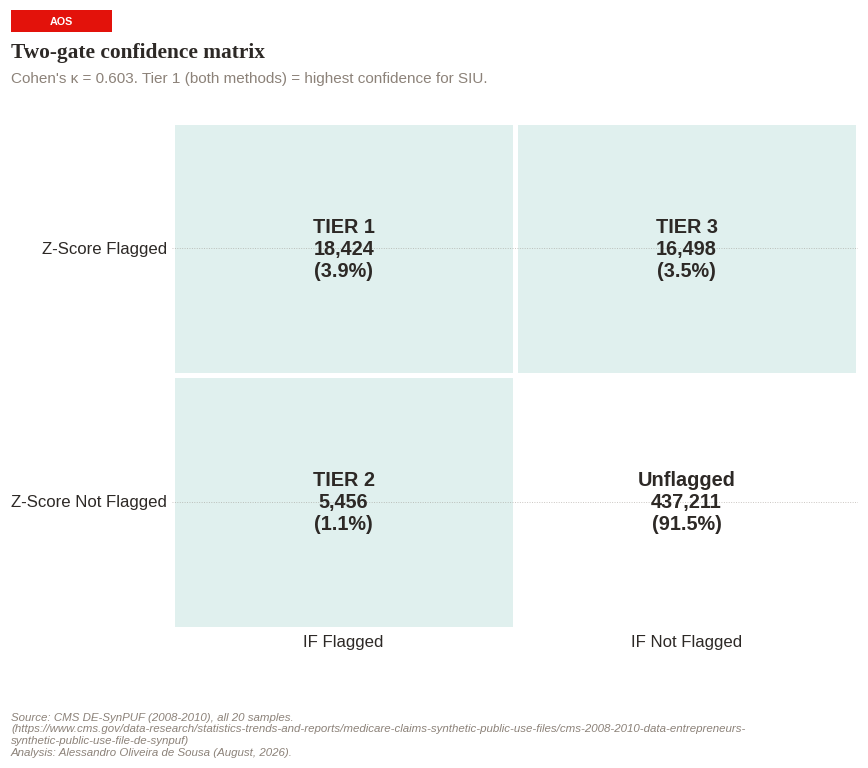

In [27]:
# =============================================================================
# Visual: two-gate matrix heatmap
# =============================================================================

matrix_data = np.array([[both, z_only], [if_only, neither]])
matrix_labels = np.array([
    [f'TIER 1\n{both:,}\n({both/total*100:.1f}%)',
     f'TIER 3\n{z_only:,}\n({z_only/total*100:.1f}%)'],
    [f'TIER 2\n{if_only:,}\n({if_only/total*100:.1f}%)',
     f'Unflagged\n{neither:,}\n({neither/total*100:.1f}%)'],
])

fig, ax = plt.subplots(figsize=(8, 6))

# Custom colormap: darker = more flags
cmap_matrix = ListedColormap([PALE_TEAL, LIGHT_GREY, ECON_BG, WHITE])

sns.heatmap(
    matrix_data, annot=matrix_labels, fmt='',
    cmap=cmap_matrix,
    linewidths=2, linecolor='white',
    cbar=False, ax=ax,
    annot_kws={'fontsize': 13, 'fontweight': 'bold', 'color': CHARCOAL},
)
ax.set_xticklabels(['IF Flagged', 'IF Not Flagged'], fontsize=11)
ax.set_yticklabels(['Z-Score Flagged', 'Z-Score Not Flagged'],
                   fontsize=11, rotation=0)
ax.tick_params(length=0)

fig_title(fig,
          title='Two-gate confidence matrix',
          subtitle=f"Cohen's κ = {kappa:.3f}. Tier 1 (both methods) = highest confidence for SIU.",
          top=0.9)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'two_gate_confidence_matrix.png')
plt.show()

## 3. Divergence analysis: why do the methods disagree?

The ~{0} IF-only and ~{1} z-only flags represent the methods' blind spots. Understanding WHY they disagree is more informative than the agreement itself:

- **IF-only flags**: providers with unusual multivariate patterns that no single metric catches. Could be complex unbundling, or could be specialty-scale artifacts (Level II codes structurally different from CPT billers).
- **Z-only flags**: providers extreme on 2+ individual metrics within their peer group, but whose overall multivariate profile isn't globally unusual. Likely single-dimension aberrance (pure upcoding, pure volume inflation).

We profile each group to determine whether the disagreement is signal or noise.

In [28]:
# =============================================================================
# Feature profiles by audit tier
# =============================================================================

profile_features = [
    'avg_paid_per_line', 'lines_per_beneficiary', 'claims_per_beneficiary',
    'hcpcs_concentration', 'pct_high_complexity_em', 'avg_diagnoses_per_claim',
    'total_paid', 'total_lines', 'distinct_beneficiaries',
]
if 'avg_beneficiary_cc_count' in df.columns:
    profile_features.append('avg_beneficiary_cc_count')

tier_profiles = {}
for tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
             'Tier 3 - Z-score statistical', 'Unflagged']:
    subset = df[df['audit_tier'] == tier]
    tier_profiles[tier] = {f: subset[f].mean() for f in profile_features}
    tier_profiles[tier]['n'] = len(subset)

df_profiles = pd.DataFrame(tier_profiles).T
render_table(
    df_profiles.round(2),
    title='Mean feature values by audit tier',
    fmt={
        'avg_paid_per_line': '${:.2f}',
        'total_paid': '${:,.0f}',
        'lines_per_beneficiary': '{:.2f}',
        'claims_per_beneficiary': '{:.2f}',
        'hcpcs_concentration': '{:.3f}',
        'pct_high_complexity_em': '{:.1f}',
        'avg_diagnoses_per_claim': '{:.2f}',
        'total_lines': '{:,.0f}',
        'distinct_beneficiaries': '{:,.0f}',
        'n': '{:,.0f}',
    }
)

avg_paid_per_line,lines_per_beneficiary,claims_per_beneficiary,hcpcs_concentration,pct_high_complexity_em,avg_diagnoses_per_claim,total_paid,total_lines,distinct_beneficiaries,avg_beneficiary_cc_count,n
$44.16,2.86,1.53,0.090,6.3,2.33,"$55,555","1,249",306,3.850000,"18,424"
$43.79,2.36,1.26,0.080,5.7,2.34,"$60,017","1,345",503,3.890000,"5,456"
$45.80,1.91,1.03,0.090,5.4,2.33,"$4,737",105,53,3.870000,"16,498"
$44.70,1.95,1.04,0.070,5.5,2.32,"$13,869",311,155,3.890000,"437,211"


In [29]:
tier_name_map = {0: 'Unknown', 1: 'Index (CPT)', 2: 'Diagnostic/Therapeutic',
                 3: 'Ancillary', 4: 'HCPCS Level II'}

In [30]:
# =============================================================================
# Specialty/tier composition: is IF-only dominated by Level II codes?
# =============================================================================

if 'top_code_tier' in df.columns:
    tier_col = 'top_code_tier'
elif 'derived_specialty' in df.columns:
    tier_col = 'derived_specialty'
else:
    tier_col = None

if tier_col:
    print("Code tier composition by audit tier:")
    print("=" * 70)

    for audit_tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
                       'Tier 3 - Z-score statistical', 'Unflagged']:
        subset = df[df['audit_tier'] == audit_tier]
        if len(subset) == 0:
            continue
        print(f"{audit_tier} (n={len(subset):,}):")
        dist = subset[tier_col].value_counts().head(5)
        for val, count in dist.items():
            pct = count / len(subset) * 100
            label = tier_name_map.get(val, str(val)) if tier_col == 'top_code_tier' else str(val)
            print(f"    {label:35s} {count:>8,} ({pct:5.1f}%)")

Code tier composition by audit tier:
Tier 1 - High confidence (n=18,424):
    Index (CPT)                           16,446 ( 89.3%)
    Ancillary                              1,369 (  7.4%)
    Diagnostic/Therapeutic                   540 (  2.9%)
    HCPCS Level II                            68 (  0.4%)
    Unknown                                    1 (  0.0%)
Tier 2 - IF multivariate (n=5,456):
    Index (CPT)                            4,474 ( 82.0%)
    Diagnostic/Therapeutic                   550 ( 10.1%)
    Ancillary                                360 (  6.6%)
    HCPCS Level II                            69 (  1.3%)
    Unknown                                    3 (  0.1%)
Tier 3 - Z-score statistical (n=16,498):
    Index (CPT)                           14,833 ( 89.9%)
    Ancillary                              1,200 (  7.3%)
    Diagnostic/Therapeutic                   426 (  2.6%)
    HCPCS Level II                            37 (  0.2%)
    Unknown                          

In [31]:
# =============================================================================
# Specialty distribution comparison: IF-only vs Z-only
# =============================================================================

if 'derived_specialty' in df.columns:
    if_only_specs = df[df['audit_tier'] == 'Tier 2 - IF multivariate']['derived_specialty'].value_counts(normalize=True)
    z_only_specs = df[df['audit_tier'] == 'Tier 3 - Z-score statistical']['derived_specialty'].value_counts(normalize=True)
    both_specs = df[df['audit_tier'] == 'Tier 1 - High confidence']['derived_specialty'].value_counts(normalize=True)

    all_specs = sorted(set(if_only_specs.index) | set(z_only_specs.index) | set(both_specs.index))

    spec_comparison = pd.DataFrame({
        'Tier 1 (Both)': [both_specs.get(s, 0) * 100 for s in all_specs],
        'Tier 2 (IF only)': [if_only_specs.get(s, 0) * 100 for s in all_specs],
        'Tier 3 (Z only)': [z_only_specs.get(s, 0) * 100 for s in all_specs],
    }, index=all_specs)

    render_table(
        spec_comparison.round(1),
        title='Specialty distribution (%) by audit tier',
        fmt={c: '{:.1f}%' for c in spec_comparison.columns}
    )

    # Check if Level II / HCPCS Level II dominates IF-only
    if 'HCPCS Level II' in if_only_specs.index:
        lvl2_pct_if = if_only_specs.get('HCPCS Level II', 0) * 100
        lvl2_pct_z = z_only_specs.get('HCPCS Level II', 0) * 100
        print(f"Level II concentration:")
        print(f"  IF-only (Tier 2): {lvl2_pct_if:.1f}%")
        print(f"  Z-only (Tier 3):  {lvl2_pct_z:.1f}%")
        if lvl2_pct_if > lvl2_pct_z * 2:
            print(f"  ⚠ IF-only flags are disproportionately Level II providers.")
            print(f"  This suggests IF is detecting structural billing differences")
            print(f"  (DME, ambulance, quality measures) rather than aberrant billing")
            print(f"  within clinical categories. In production, Level II providers")
            print(f"  would be modeled in a separate IF instance.")
        else:
            print(f"  Level II distribution is similar across tiers - IF-only flags")
            print(f"  represent genuine multivariate anomalies, not scale artifacts.")

Tier 1 (Both),Tier 2 (IF only),Tier 3 (Z only)
89.2%,81.9%,89.8%
0.2%,0.5%,0.1%
1.3%,4.3%,1.1%
0.2%,0.8%,0.1%
1.4%,4.8%,1.3%
0.2%,1.0%,0.3%
7.5%,6.8%,7.4%


Level II concentration:
  IF-only (Tier 2): 0.5%
  Z-only (Tier 3):  0.1%
  ⚠ IF-only flags are disproportionately Level II providers.
  This suggests IF is detecting structural billing differences
  (DME, ambulance, quality measures) rather than aberrant billing
  within clinical categories. In production, Level II providers
  would be modeled in a separate IF instance.


## 4. Visualizations

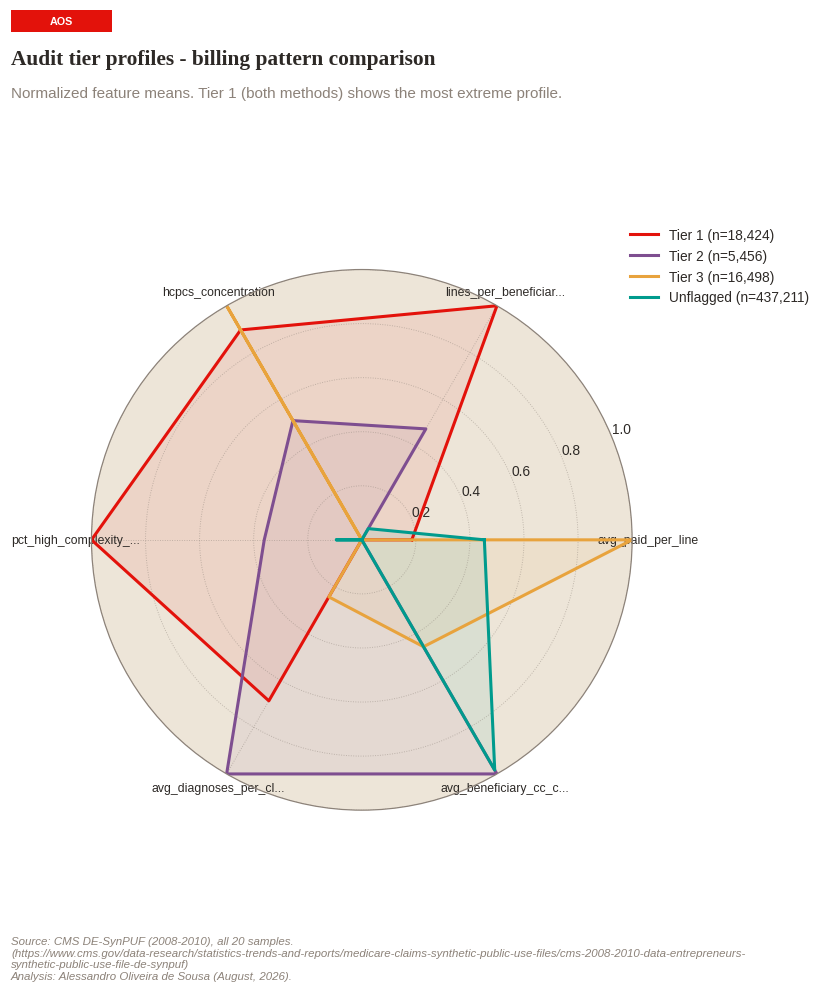

In [32]:
# =============================================================================
# 4.1 - Radar chart: tier profiles
# =============================================================================

radar_features = ['avg_paid_per_line', 'lines_per_beneficiary',
                  'hcpcs_concentration', 'pct_high_complexity_em',
                  'avg_diagnoses_per_claim']
if 'avg_beneficiary_cc_count' in df.columns:
    radar_features.append('avg_beneficiary_cc_count')

# Normalize to 0-1 using global min/max
tier_means = {}
for tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
             'Tier 3 - Z-score statistical', 'Unflagged']:
    subset = df[df['audit_tier'] == tier]
    tier_means[tier] = {f: subset[f].mean() for f in radar_features}

df_radar = pd.DataFrame(tier_means).T
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

tier_colors = {
    'Tier 1 - High confidence': ECON_RED,
    'Tier 2 - IF multivariate': PLUM,
    'Tier 3 - Z-score statistical': AMBER,
    'Unflagged': NATURE_TEAL,
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for tier_name, color in tier_colors.items():
    values = df_radar_norm.loc[tier_name].values.tolist()
    values += values[:1]
    n_tier = (df['audit_tier'] == tier_name).sum()
    ax.plot(angles, values, linewidth=2, color=color,
            label=f'{tier_name.split(" - ")[0]} (n={n_tier:,})')
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([truncar(f, 20) for f in radar_features], fontsize=8)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

fig_title(fig,
          title='Audit tier profiles - billing pattern comparison',
          subtitle='Normalized feature means. Tier 1 (both methods) shows the most extreme profile.',
          top=0.88)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'tier_radar_profiles.png')
plt.show()

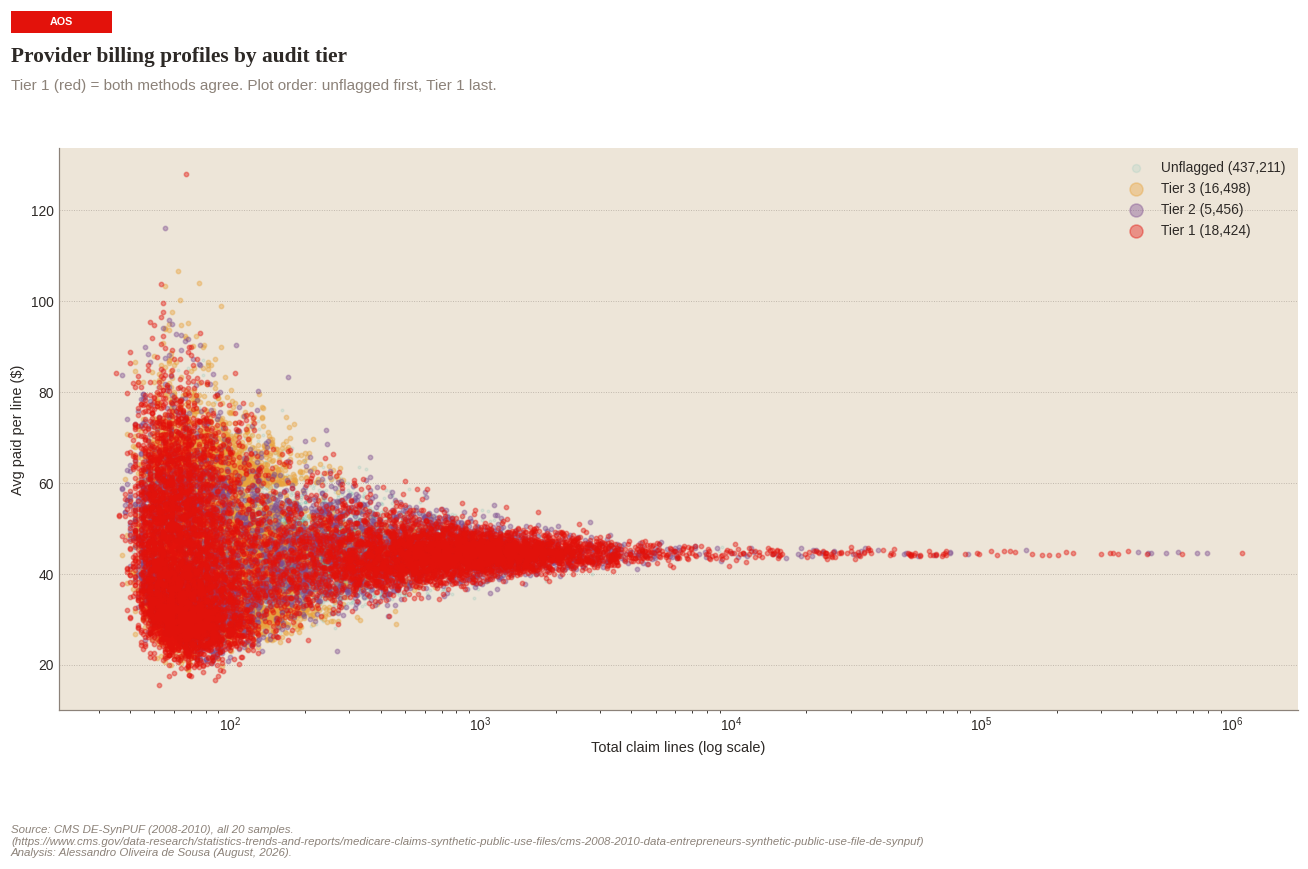

In [33]:
# =============================================================================
# 4.2 - Volume vs intensity by audit tier
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

for tier_name, color in [('Unflagged', NATURE_TEAL),
                          ('Tier 3 - Z-score statistical', AMBER),
                          ('Tier 2 - IF multivariate', PLUM),
                          ('Tier 1 - High confidence', ECON_RED)]:
    subset = df[df['audit_tier'] == tier_name]
    # Sample for dense tiers
    if len(subset) > 10_000:
        subset = subset.sample(10_000, random_state=42)
    alpha = 0.08 if tier_name == 'Unflagged' else 0.4
    size = 3 if tier_name == 'Unflagged' else 8
    ax.scatter(subset['total_lines'], subset['avg_paid_per_line'],
               s=size, alpha=alpha, color=color,
               label=f'{tier_name.split(" - ")[0]} ({(df["audit_tier"] == tier_name).sum():,})',
               rasterized=True)

ax.set_xscale('log')
adjust_axis(ax, xlabel='Total claim lines (log scale)', ylabel='Avg paid per line ($)')
ax.legend(fontsize=9, markerscale=3, loc='upper right')

fig_title(fig,
          title='Provider billing profiles by audit tier',
          subtitle='Tier 1 (red) = both methods agree. Plot order: unflagged first, Tier 1 last.',
          top=0.88)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'volume_vs_intensity_by_tier.png')
plt.show()

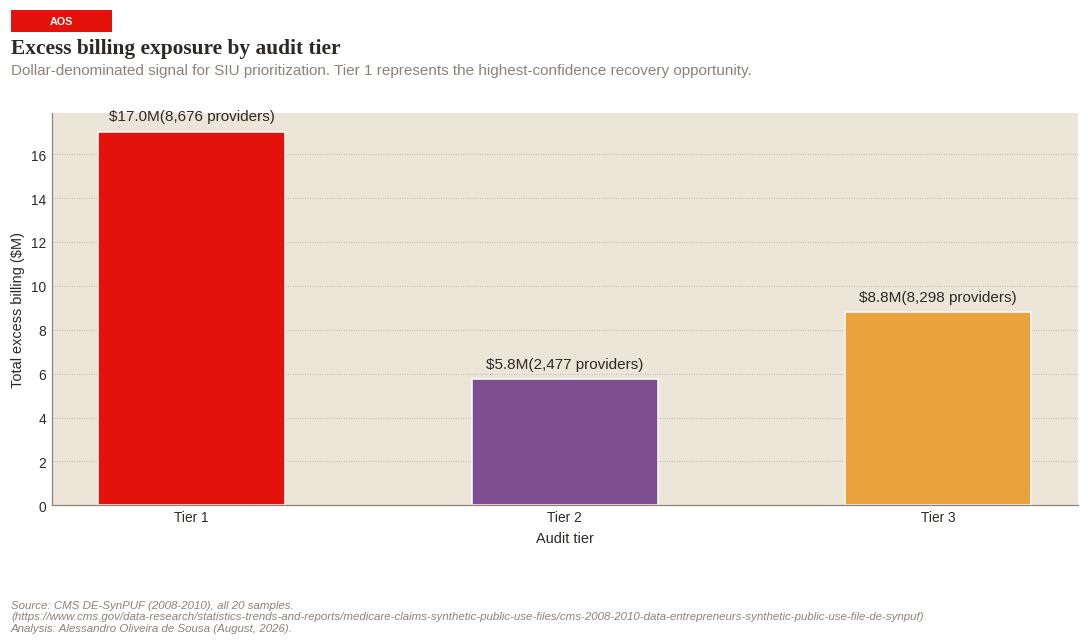

Tier,Providers,Total excess,Mean excess,Median excess
Tier 1,"8,676","$17,040,354","$1,964","$1,110"
Tier 2,"2,477","$5,776,506","$2,332","$1,064"
Tier 3,"8,298","$8,798,482","$1,060",$870


In [34]:
# =============================================================================
# 4.3 - Excess billing by tier
# =============================================================================

if 'excess_billing' in df.columns:
    tier_excess = []
    for tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
                 'Tier 3 - Z-score statistical']:
        subset = df[(df['audit_tier'] == tier) & (df['excess_billing'] > 0)]
        tier_excess.append({
            'Tier': tier.split(' - ')[0],
            'Providers': len(subset),
            'Total excess': subset['excess_billing'].sum(),
            'Mean excess': subset['excess_billing'].mean(),
            'Median excess': subset['excess_billing'].median(),
        })

    df_excess = pd.DataFrame(tier_excess)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(df_excess['Tier'], df_excess['Total excess'] / 1e6,
                  color=[ECON_RED, PLUM, AMBER], edgecolor='white', width=0.5)

    for bar, row in zip(bars, df_excess.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'${row._3/1e6:.1f}M({row.Providers:,} providers)',
                ha='center', fontsize=10, color=CHARCOAL)

    adjust_axis(ax, xlabel='Audit tier', ylabel='Total excess billing ($M)')
    fig_title(fig,
              title='Excess billing exposure by audit tier',
              subtitle='Dollar-denominated signal for SIU prioritization. '
                       'Tier 1 represents the highest-confidence recovery opportunity.',
              top=0.9)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'excess_billing_by_tier.png')
    plt.show()

    render_table(df_excess, title='Excess billing by audit tier',
                 fmt={'Total excess': '${:,.0f}', 'Mean excess': '${:,.0f}',
                      'Median excess': '${:,.0f}', 'Providers': '{:,}'})

## 5. Statistical validation of tier separation

### 5.1 Are the tiers statistically distinct?

We test whether the feature distributions differ significantly across tiers using the Kruskal-Wallis H-test (non-parametric, appropriate given the non-normal distributions confirmed in NB02b).

In [35]:
# =============================================================================
# Kruskal-Wallis: are tiers distinct on each feature?
# =============================================================================

test_features = ['avg_paid_per_line', 'lines_per_beneficiary',
                 'claims_per_beneficiary', 'hcpcs_concentration',
                 'total_paid']

kw_results = []
for feat in test_features:
    groups = [df.loc[df['audit_tier'] == tier, feat].dropna().values
              for tier in ['Tier 1 - High confidence', 'Tier 2 - IF multivariate',
                          'Tier 3 - Z-score statistical', 'Unflagged']]
    groups = [g for g in groups if len(g) > 0]

    stat, pval = stats.kruskal(*groups)
    kw_results.append({
        'Feature': feat,
        'H-statistic': round(stat, 2),
        'p-value': f'{pval:.2e}' if pval < 0.001 else f'{pval:.4f}',
        'Significant': '✓' if pval < 0.001 else '✗',
    })

df_kw = pd.DataFrame(kw_results)
render_table(df_kw, title='Kruskal-Wallis test: tier separation by feature')

n_sig = sum(1 for r in kw_results if r['Significant'] == '✓')
print(f"{n_sig}/{len(kw_results)} features show significant tier separation (p < 0.001).")
print("The audit tiers represent statistically distinct billing profiles,")
print("not arbitrary partitions.")

Feature,H-statistic,p-value,Significant
avg_paid_per_line,360.110000,9.63e-78,✓
lines_per_beneficiary,11879.440000,0.00e+00,✓
claims_per_beneficiary,13733.120000,0.00e+00,✓
hcpcs_concentration,13132.100000,0.00e+00,✓
total_paid,16899.210000,0.00e+00,✓


5/5 features show significant tier separation (p < 0.001).
The audit tiers represent statistically distinct billing profiles,
not arbitrary partitions.


### 5.2 Three-way concordance (Python z-score × IF × SAS)

If SAS flags are available, we compute three-way agreement. This validates that the z-score implementation produces consistent results across technologies.

In [36]:
# =============================================================================
# Three-way concordance (if SAS available)
# =============================================================================

if has_sas and df['flag_sas'].any():
    sas_flag = df['flag_sas'].values

    # Z vs SAS
    kappa_z_sas = cohen_kappa_score(z_flag.astype(int), sas_flag.astype(int))
    both_z_sas = (z_flag & sas_flag).sum()

    # IF vs SAS
    kappa_if_sas = cohen_kappa_score(if_flag.astype(int), sas_flag.astype(int))
    both_if_sas = (if_flag & sas_flag).sum()

    # All three
    all_three = (z_flag & if_flag & sas_flag).sum()

    print("Three-way concordance:")
    print("=" * 60)
    print(f"  Z-score ∩ SAS:   κ = {kappa_z_sas:.4f}  ({both_z_sas:,} shared flags)")
    print(f"  IF ∩ SAS:        κ = {kappa_if_sas:.4f}  ({both_if_sas:,} shared flags)")
    print(f"  Z-score ∩ IF:    κ = {kappa:.4f}  ({both:,} shared flags)")
    print(f"  All three:       {all_three:,} providers flagged by all methods")
    print()

    if kappa_z_sas > 0.8:
        print("  ✓ Z-score and SAS show strong agreement - cross-technology")
        print("  validation confirms the statistical approach is robust.")
    elif kappa_z_sas > 0.5:
        print("  Z-score and SAS show moderate agreement. Differences likely stem")
        print("  from implementation details (log-transform, peer group boundaries).")
    else:
        print("  ⚠ Low Z-SAS agreement. Investigate: different peer group definitions,")
        print("  different feature sets, or different flagging criteria.")
else:
    print("SAS flags not available. Two-method validation (z-score × IF) is the")
    print("primary framework. Run SAS 02_peer_comparison.sas and re-run this")
    print("notebook for three-way validation.")
    print()
    print("Even without SAS, the two-gate matrix provides a defensible tiering")
    print("framework: Tier 1 (both methods) captures the highest-confidence flags.")

Three-way concordance:
  Z-score ∩ SAS:   κ = 0.2681  (23,894 shared flags)
  IF ∩ SAS:        κ = 0.2286  (18,390 shared flags)
  Z-score ∩ IF:    κ = 0.6031  (18,424 shared flags)
  All three:       14,769 providers flagged by all methods

  ⚠ Low Z-SAS agreement. Investigate: different peer group definitions,
  different feature sets, or different flagging criteria.


### 5.3 Cross-validation against Snowflake z-scores

The Snowflake layer computed z-scores using broad specialty groups (naive approach). Python uses HCPCS-level groups (improved approach). We expect moderate agreement - perfect agreement would mean the methodology improvement had no effect.

In [37]:
# =============================================================================
# Load Snowflake z-score export for cross-validation
# =============================================================================

try:
    df_sf = load_snowflake_export('zscore_flags')

    df_cross = df[['provider_npi', 'flag_zscore_2', 'audit_tier']].merge(
        df_sf[['provider_npi', 'flag_zscore_2']].rename(
            columns={'flag_zscore_2': 'flag_sf_zscore'}),
        on='provider_npi', how='inner'
    )

    # Handle Snowflake boolean encoding (may be string 'TRUE'/'FALSE')
    df_cross['flag_sf_zscore'] = _safe_bool(df_cross['flag_sf_zscore'])

    n_matched = len(df_cross)
    n_agree = (df_cross['flag_zscore_2'] == df_cross['flag_sf_zscore']).sum()
    kappa_sf = cohen_kappa_score(
        df_cross['flag_zscore_2'].astype(int),
        df_cross['flag_sf_zscore'].astype(int)
    )

    print(f"Python vs Snowflake z-score flags:")
    print("=" * 60)
    print(f"  Providers matched:  {n_matched:,}")
    print(f"  Agreement:          {n_agree/n_matched*100:.1f}%")
    print(f"  Cohen's Kappa:      {kappa_sf:.4f}")
    print()
    print(f"  Note: < 100% agreement is EXPECTED. Python uses HCPCS-level")
    print(f"  peer groups with conjunction rule (≥2 metrics), while Snowflake")
    print(f"  uses broad specialty groups with any-metric flagging. The")
    print(f"  difference reflects deliberate methodology improvement, not bugs.")
    print()
    print(f"  For context: if Snowflake used the same HCPCS-level grouping and")
    print(f"  conjunction rule, agreement would be near-perfect. The low κ reflects")
    print(f"  the cumulative impact of three deliberate methodology changes:")
    print(f"  (1) HCPCS-level peer groups, (2) conjunction rule (≥2 metrics),")
    print(f"  (3) MIN_CLAIMS raised from 5 to 30.")

except (FileNotFoundError, KeyError) as e:
    print(f"Snowflake z-score export not found: {e}")
    print("Cross-validation skipped.")


Python vs Snowflake z-score flags:
  Providers matched:  477,589
  Agreement:          82.2%
  Cohen's Kappa:      0.2566

  Note: < 100% agreement is EXPECTED. Python uses HCPCS-level
  peer groups with conjunction rule (≥2 metrics), while Snowflake
  uses broad specialty groups with any-metric flagging. The
  difference reflects deliberate methodology improvement, not bugs.

  For context: if Snowflake used the same HCPCS-level grouping and
  conjunction rule, agreement would be near-perfect. The low κ reflects
  the cumulative impact of three deliberate methodology changes:
  (1) HCPCS-level peer groups, (2) conjunction rule (≥2 metrics),
  (3) MIN_CLAIMS raised from 5 to 30.


## 6. Tier 1 deep dive - highest confidence flags

In [38]:
# =============================================================================
# Top 20 Tier 1 providers by excess billing
# =============================================================================

tier1 = df[df['audit_tier'] == 'Tier 1 - High confidence'].copy()

display_cols = ['provider_npi', 'derived_specialty',
                'total_lines', 'total_paid', 'avg_paid_per_line',
                'lines_per_beneficiary', 'hcpcs_concentration',
                'z_max_abs', 'if_score']

if 'excess_billing' in tier1.columns:
    tier1_top = tier1.nlargest(20, 'excess_billing')
    display_cols.append('excess_billing')
else:
    tier1_top = tier1.nlargest(20, 'z_max_abs')

if 'cluster' in tier1.columns:
    display_cols.append('cluster')

available_cols = [c for c in display_cols if c in tier1_top.columns]

render_table(
    tier1_top[available_cols].reset_index(drop=True),
    title='Top 20 Tier 1 providers (highest confidence, by excess billing)',
    fmt={
        'total_paid': '${:,.0f}',
        'avg_paid_per_line': '${:.2f}',
        'lines_per_beneficiary': '{:.1f}',
        'hcpcs_concentration': '{:.3f}',
        'z_max_abs': '{:.2f}',
        'if_score': '{:.4f}',
        'excess_billing': '${:,.0f}',
    }
)

provider_npi,derived_specialty,total_lines,total_paid,avg_paid_per_line,lines_per_beneficiary,hcpcs_concentration,z_max_abs,if_score,excess_billing,cluster
888901330,Evaluation & Management,1092413,"$48,669,250",$44.55,3.1,0.068,9.28,-0.0884,"$239,570",1
7132269719,Evaluation & Management,384315,"$17,275,420",$44.95,4.5,0.069,8.14,-0.1784,"$237,676",1
4332659805,Evaluation & Management,338705,"$15,148,350",$44.72,6.7,0.068,11.04,-0.1980,"$132,623",1
5040521237,Evaluation & Management,335147,"$14,969,520",$44.67,4.0,0.068,7.98,-0.1511,"$111,529",1
6804338533,Evaluation & Management,130186,"$5,874,570",$45.12,9.1,0.067,16.78,-0.2067,"$103,066",1
3517371403,Evaluation & Management,335190,"$14,956,690",$44.62,5.2,0.068,7.98,-0.1862,"$96,793",1
2503159927,Evaluation & Management,217344,"$9,729,380",$44.76,4.9,0.068,7.51,-0.1846,"$93,921",1
8698467005,Evaluation & Management,102232,"$4,617,600",$45.17,5.9,0.067,9.22,-0.1982,"$85,374",1
1117051864,Evaluation & Management,135732,"$6,092,400",$44.89,4.4,0.067,6.99,-0.1728,"$75,026",1
6955475791,Evaluation & Management,325738,"$14,515,770",$44.56,6.2,0.068,9.92,-0.1983,"$74,906",1


In [39]:
# =============================================================================
# Z-score heatmap for Tier 1 top 20
# =============================================================================

z_cols = [c for c in tier1_top.columns if c.startswith('z_') and c != 'z_max_abs']

if z_cols:
    heatmap_labels = {
        'z_log_avg_paid': 'Avg paid',
        'z_lines_per_beneficiary': 'Lines/bene',
        'z_claims_per_beneficiary': 'Claims/bene',
        'z_hcpcs_concentration': 'HCPCS conc.',
        'z_pct_high_complexity_em': 'High E&M %',
        'z_avg_diagnoses_per_claim': 'Avg Dx/claim',
        'z_log_total_paid': 'Total paid',
        'z_avg_beneficiary_cc_count': 'Case-mix',
    }

    available_z = [c for c in z_cols if c in heatmap_labels]
    heatmap_df = tier1_top.set_index('provider_npi')[available_z].copy()
    heatmap_df.columns = [heatmap_labels.get(c, c) for c in available_z]

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        heatmap_df, annot=True, fmt='.1f',
        cmap='RdYlGn_r', center=0,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'z-score', 'shrink': 0.8},
        ax=ax
    )
    ax.set_ylabel('Provider NPI')

    fig_title(fig,
              title='Z-score profile: Tier 1 providers (top 20 by excess billing)',
              subtitle='Red = billing above peers. These are the highest-confidence investigation targets.',
              top=0.90)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'tier1_zscore_heatmap.png')
    plt.show()

## 7. Export for Notebook 05 (business impact & triage)

In [40]:
# =============================================================================
# Export: full provider matrix with audit tiers
# =============================================================================

export_path = OUTPUT_DIR / 'nb04_providers_with_audit_tiers.csv'
df.to_csv(export_path, index=False)

print(f"Exported: {len(df):,} providers × {len(df.columns)} columns")
print(f"File: exported to nb04_providers_with_audit_tiers.csv")
print(f"\nNew column: audit_tier")
print(f"  Tier 1 - High confidence:       {(df['audit_tier'] == 'Tier 1 - High confidence').sum():,}")
print(f"  Tier 2 - IF multivariate:       {(df['audit_tier'] == 'Tier 2 - IF multivariate').sum():,}")
print(f"  Tier 3 - Z-score statistical:   {(df['audit_tier'] == 'Tier 3 - Z-score statistical').sum():,}")
print(f"  Unflagged:                      {(df['audit_tier'] == 'Unflagged').sum():,}")
print(f"\nThis CSV feeds: Notebook 05 (business impact & case file generation)")

Exported: 477,589 providers × 33 columns
File: exported to nb04_providers_with_audit_tiers.csv

New column: audit_tier
  Tier 1 - High confidence:       18,424
  Tier 2 - IF multivariate:       5,456
  Tier 3 - Z-score statistical:   16,498
  Unflagged:                      437,211

This CSV feeds: Notebook 05 (business impact & case file generation)


In [41]:
print("=" * 70)
print("Notebook 04 - Cross-Method Validation - Summary")
print("=" * 70)
print(f"  Providers:                 {total:,}")
print(f"  Z-score flagged:           {z_flag.sum():,} ({z_flag.sum()/total*100:.2f}%)")
print(f"  IF flagged:                {if_flag.sum():,} ({if_flag.sum()/total*100:.2f}%)")
print(f"  Cohen's Kappa (Z × IF):    {kappa:.4f}")
print(f"")
print(f"  Tier 1 (Both):             {both:,} ({both/total*100:.2f}%)")
print(f"  Tier 2 (IF only):          {if_only:,} ({if_only/total*100:.2f}%)")
print(f"  Tier 3 (Z only):           {z_only:,} ({z_only/total*100:.2f}%)")
if 'excess_billing' in df.columns:
    t1_excess = df.loc[(df['audit_tier'] == 'Tier 1 - High confidence') & (df['excess_billing'] > 0), 'excess_billing'].sum()
    flagged_mask = df['audit_tier'] != 'Unflagged'
    total_excess = df.loc[flagged_mask & (df['excess_billing'] > 0), 'excess_billing'].sum()
    print(f"")
    print(f"  Tier 1 excess billing:     ${t1_excess:,.0f}")
    print(f"  Total excess (all tiers):  ${total_excess:,.0f}")
if has_sas and df['flag_sas'].any():
    print(f"")
    print(f"  SAS concordance (Z × SAS): κ = {kappa_z_sas:.4f}")
    print(f"  All three methods:         {all_three:,}")
print(f"")
print(f"  Figures: exported to the figures folder.")
print("=" * 70)
print("\nProceed to: Notebook 05 (business impact & case file generation)")

Notebook 04 - Cross-Method Validation - Summary
  Providers:                 477,589
  Z-score flagged:           34,922 (7.31%)
  IF flagged:                23,880 (5.00%)
  Cohen's Kappa (Z × IF):    0.6031

  Tier 1 (Both):             18,424 (3.86%)
  Tier 2 (IF only):          5,456 (1.14%)
  Tier 3 (Z only):           16,498 (3.45%)

  Tier 1 excess billing:     $17,040,354
  Total excess (all tiers):  $31,615,341

  SAS concordance (Z × SAS): κ = 0.2681
  All three methods:         14,769

  Figures: exported to the figures folder.

Proceed to: Notebook 05 (business impact & case file generation)
